# Loading and data processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import scipy
import scipy.stats as stats
import scikit_posthocs as sp

from IPython.display import display

from termcolor import colored, cprint

from pathlib import Path

plt.rcParams['figure.figsize'] = [25, 10]
# sn.set_theme(style="darkgrid", font_scale=2)
sn.set_theme(style="ticks")

In [2]:
EXPERIMENTS_DIR = ["denser_with_power_measure", "energize_power_10", "energize_power_norm", "energize_power_norm_seed"]

EXPERIMENTS = ("DENSER", "ENERGIZE", "ENERGIZE (norm)", "ENERGIZE (norm w/ seed)")
EXPERIMENTS_WITH_SEED = EXPERIMENTS #+ ("ENERGIZE (w/ seed)",)

# DATASET = "fashionmnist"
DATASET = "cifar10"
# DATASET = "cifar100"


for i in range(1, len(EXPERIMENTS_DIR)):
    if DATASET != "fashionmnist" and EXPERIMENTS_DIR[i] not in ("energize_power_norm", "energize_power_norm_seed"):
        EXPERIMENTS_DIR[i] = f"{EXPERIMENTS_DIR[i]}_{DATASET}"

KEYS = ("fitness", "n_trainable_parameters", "accuracy_0", "accuracy_1",
        "power_train", "power_test_0_mean", "power_test_1_mean", "early_stop")

# KEYS = ("n_trainable_parameters",
#         "n_layers_0", "n_layers_1", "accuracy_0", "accuracy_1",
#         "power_train", "power_test_0_mean", "power_test_1_mean",\
#                 "energy_train", "energy_test_0_mean", "energy_test_1_mean")

KEYS_ENERGIZE_TO_DENSER = {
    'n_layers_0': 'n_layers',
    'n_layers_1': 'n_layers',
    'accuracy_0': 'accuracy',
    'accuracy_1': 'accuracy',
    'power_test_0_mean': 'power_test_mean',
    'power_test_1_mean': 'power_test_mean',
    'energy_test_0_mean': 'energy_test_mean',
    'energy_test_1_mean': 'energy_test_mean'
}

In [3]:
experiments_data = {}

for experiment_dir, experiment in zip(EXPERIMENTS_DIR, EXPERIMENTS_WITH_SEED):
    experiments_data[experiment] = {}
    experiments_data[experiment]['data'] = pd.read_csv(
        f"../experiments/{DATASET}/{experiment_dir}/data.csv")
    experiments_data[experiment]['shapiro'] = {}

In [4]:
for experiment in EXPERIMENTS_WITH_SEED:
    max_gen = experiments_data[experiment]['data']['gen'].max()
    print(f"Experiment: {experiment}, Max gen: {max_gen}")

Experiment: DENSER, Max gen: 149
Experiment: ENERGIZE, Max gen: 149
Experiment: ENERGIZE (norm), Max gen: 249
Experiment: ENERGIZE (norm w/ seed), Max gen: 154


In [5]:
CUTOFF_GEN = 150

# cut off at 150 gens
for experiment_dir, experiment in zip(EXPERIMENTS_DIR, EXPERIMENTS_WITH_SEED):
    experiments_data[experiment]['data'] = experiments_data[experiment]['data'][experiments_data[experiment]['data']['gen'] < CUTOFF_GEN]
    experiments_data[experiment]['data']['early_stop'] = experiments_data[experiment]['data']['phenotype'].str.extract(r'early_stop:(\d+)').astype(int)
    if experiment != 'DENSER':
        experiments_data[experiment]['data']['power_test_diff'] = experiments_data[experiment]['data']['power_test_1_mean'] - experiments_data[experiment]['data']['power_test_0_mean']

In [6]:
for experiment in EXPERIMENTS_WITH_SEED:
    max_gen = experiments_data[experiment]['data']['gen'].max()
    print(f"Experiment: {experiment}, Max gen: {max_gen}")

Experiment: DENSER, Max gen: 149
Experiment: ENERGIZE, Max gen: 149
Experiment: ENERGIZE (norm), Max gen: 149
Experiment: ENERGIZE (norm w/ seed), Max gen: 149


In [7]:
a = experiments_data['ENERGIZE']['data']['accuracy_0'] - experiments_data['ENERGIZE']['data']['accuracy_1']
print(f"accuracy\n{a.min():10.2e}")
print(f"{a.max():10.2e}")
print(f"{a.mean():10.5f}\n")

a = experiments_data['ENERGIZE']['data']['power_test_0_mean'] - experiments_data['ENERGIZE']['data']['power_test_1_mean']
print(f"power\n{a.min():10.2e}")
print(f"{a.max():10.2e}")
print(f"{a.mean():10.5f}")

accuracy
 -9.00e-02
  1.32e-01
   0.00638

power
 -3.50e+01
  4.43e+01
   6.86875


# Statistic tests

#### Stats config


In [8]:
alpha = 0.05

Everything assumes the data does not follow a normal dist

Experiment: DENSER


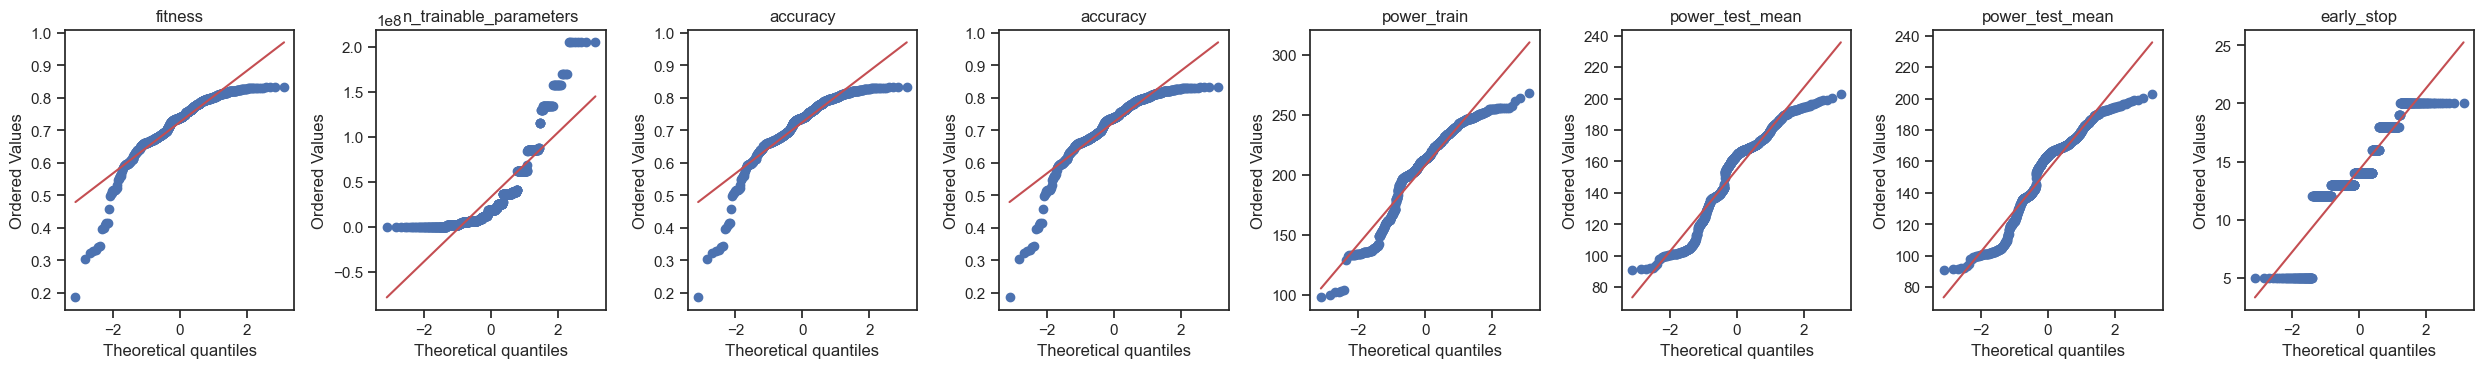

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.87 | 8.46e-25
....n_trainable_parameters   False | 0.75 | 2.76e-32
....accuracy                 False | 0.87 | 8.46e-25
....accuracy                 False | 0.87 | 8.46e-25
....power_train              False | 0.93 | 1.63e-18
....power_test_mean          False | 0.93 | 1.06e-17
....power_test_mean          False | 0.93 | 1.06e-17
....early_stop               False | 0.87 | 3.19e-24



,fitness,n_trainable_parameters,accuracy,accuracy,power_train,power_test_mean,power_test_mean,early_stop
fitness,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
n_trainable_parameters,-0.139084,1.000000,-0.139084,-0.139084,0.524891,0.609361,0.609361,-0.071558
accuracy,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
accuracy,1.000000,-0.139084,1.000000,1.000000,0.208559,0.360469,0.360469,0.202029
power_train,0.208559,0.524891,0.208559,0.208559,1.000000,0.863574,0.863574,-0.042385
power_test_mean,0.360469,0.609361,0.360469,0.360469,0.863574,1.000000,1.000000,-0.064286
power_test_mean,0.360469,0.609361,0.360469,0.360469,0.863574,1.000000,1.000000,-0.064286
early_stop,0.202029,-0.071558,0.202029,0.202029,-0.042385,-0.064286,-0.064286,1.000000


,fitness,n_trainable_parameters,accuracy,accuracy,power_train,power_test_mean,power_test_mean,early_stop
fitness,1.000000e+00,1.328056e-04,0.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
n_trainable_parameters,1.328056e-04,1.000000e+00,1.328056e-04,1.328056e-04,2.484518e-54,1.956225e-77,1.956225e-77,5.011875e-02
accuracy,0.000000e+00,1.328056e-04,1.000000e+00,0.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
accuracy,0.000000e+00,1.328056e-04,0.000000e+00,1.000000e+00,8.135556e-09,1.976654e-24,1.976654e-24,2.388369e-08
power_train,8.135556e-09,2.484518e-54,8.135556e-09,8.135556e-09,1.000000e+00,1.229096e-224,1.229096e-224,2.463176e-01
power_test_mean,1.976654e-24,1.956225e-77,1.976654e-24,1.976654e-24,1.229096e-224,1.000000e+00,0.000000e+00,7.850543e-02
power_test_mean,1.976654e-24,1.956225e-77,1.976654e-24,1.976654e-24,1.229096e-224,0.000000e+00,1.000000e+00,7.850543e-02
early_stop,2.388369e-08,5.011875e-02,2.388369e-08,2.388369e-08,2.463176e-01,7.850543e-02,7.850543e-02,1.000000e+00


Experiment: ENERGIZE


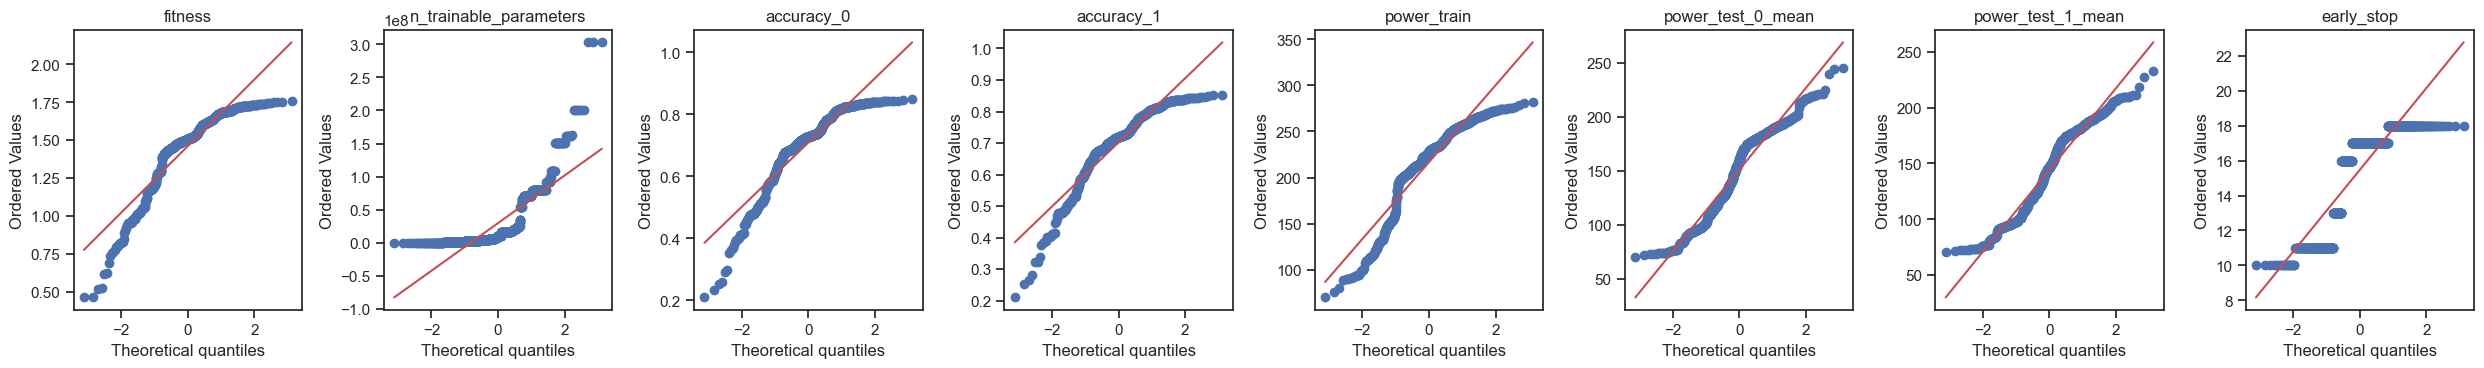

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.87 | 1.10e-24
....n_trainable_parameters   False | 0.68 | 1.75e-35
....accuracy_0               False | 0.88 | 2.99e-23
....accuracy_1               False | 0.90 | 2.11e-21
....power_train              False | 0.89 | 4.20e-23
....power_test_0_mean        False | 0.95 | 1.01e-15
....power_test_1_mean        False | 0.95 | 1.24e-14
....early_stop               False | 0.76 | 8.01e-32



,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000,-0.148017,0.981840,0.993639,0.681314,0.699393,0.767230,0.229172
n_trainable_parameters,-0.148017,1.000000,-0.083015,-0.134091,0.148619,0.246493,0.147920,-0.101441
accuracy_0,0.981840,-0.083015,1.000000,0.969854,0.716039,0.756977,0.803238,0.256552
accuracy_1,0.993639,-0.134091,0.969854,1.000000,0.696023,0.721890,0.792179,0.219527
power_train,0.681314,0.148619,0.716039,0.696023,1.000000,0.835215,0.826758,0.232091
power_test_0_mean,0.699393,0.246493,0.756977,0.721890,0.835215,1.000000,0.961418,0.255059
power_test_1_mean,0.767230,0.147920,0.803238,0.792179,0.826758,0.961418,1.000000,0.238501
early_stop,0.229172,-0.101441,0.256552,0.219527,0.232091,0.255059,0.238501,1.000000


,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000e+00,4.715809e-05,0.000000e+00,0.000000e+00,1.911453e-103,3.318353e-111,1.985055e-146,2.147936e-10
n_trainable_parameters,4.715809e-05,1.000000e+00,2.299129e-02,2.307183e-04,4.388292e-05,7.641168e-12,4.770551e-05,5.425638e-03
accuracy_0,0.000000e+00,2.299129e-02,1.000000e+00,0.000000e+00,6.938123e-119,2.289274e-140,1.809212e-170,9.749695e-13
accuracy_1,0.000000e+00,2.307183e-04,0.000000e+00,1.000000e+00,1.026471e-109,1.020638e-121,1.400588e-162,1.230378e-09
power_train,1.911453e-103,4.388292e-05,6.938123e-119,1.026471e-109,1.000000e+00,1.945901e-196,4.700428e-189,1.246814e-10
power_test_0_mean,3.318353e-111,7.641168e-12,2.289274e-140,1.020638e-121,1.945901e-196,1.000000e+00,0.000000e+00,1.331161e-12
power_test_1_mean,1.985055e-146,4.770551e-05,1.809212e-170,1.400588e-162,4.700428e-189,0.000000e+00,1.000000e+00,3.679530e-11
early_stop,2.147936e-10,5.425638e-03,9.749695e-13,1.230378e-09,1.246814e-10,1.331161e-12,3.679530e-11,1.000000e+00


Experiment: ENERGIZE (norm)


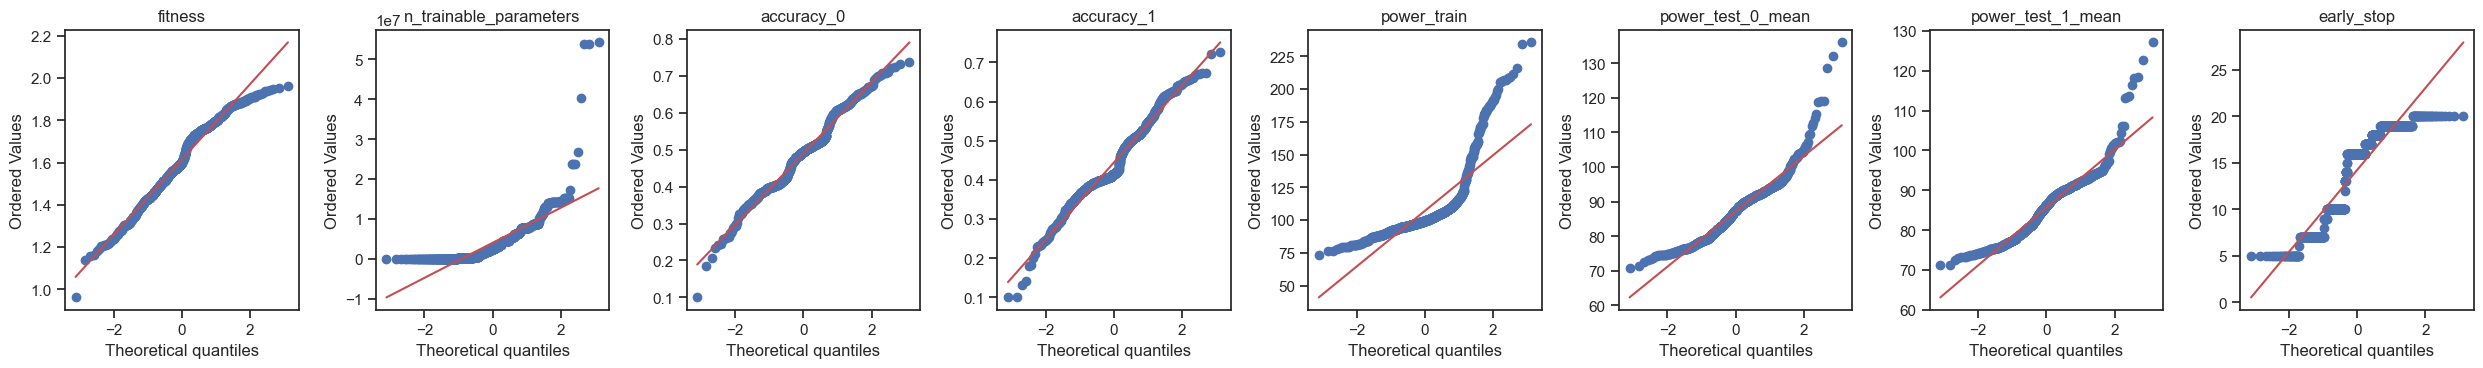

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.97 | 2.84e-10
....n_trainable_parameters   False | 0.66 | 3.97e-36
....accuracy_0               False | 0.98 | 5.20e-07
....accuracy_1               False | 0.98 | 1.36e-09
....power_train              False | 0.70 | 1.88e-34
....power_test_0_mean        False | 0.93 | 7.10e-18
....power_test_1_mean        False | 0.94 | 2.22e-17
....early_stop               False | 0.86 | 2.52e-25



,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000,0.142940,0.728062,0.709741,-0.105022,-0.584856,-0.593546,0.121758
n_trainable_parameters,0.142940,1.000000,0.084269,0.083833,0.374150,0.213253,0.125258,0.210863
accuracy_0,0.728062,0.084269,1.000000,0.701891,0.375105,-0.116082,-0.166805,0.230520
accuracy_1,0.709741,0.083833,0.701891,1.000000,0.169125,-0.228462,-0.192767,0.262768
power_train,-0.105022,0.374150,0.375105,0.169125,1.000000,0.630853,0.543791,0.163047
power_test_0_mean,-0.584856,0.213253,-0.116082,-0.228462,0.630853,1.000000,0.972805,0.180497
power_test_1_mean,-0.593546,0.125258,-0.166805,-0.192767,0.543791,0.972805,1.000000,0.193834
early_stop,0.121758,0.210863,0.230520,0.262768,0.163047,0.180497,0.193834,1.000000


,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000e+00,8.557107e-05,8.731166e-125,6.470952e-116,3.985321e-03,5.001465e-70,1.396451e-72,8.337111e-04
n_trainable_parameters,8.557107e-05,1.000000e+00,2.099632e-02,2.167170e-02,2.471256e-26,3.670205e-09,5.856755e-04,5.516741e-09
accuracy_0,8.731166e-125,2.099632e-02,1.000000e+00,2.527013e-112,1.805573e-26,1.449968e-03,4.374927e-06,1.672347e-10
accuracy_1,6.470952e-116,2.167170e-02,2.527013e-112,1.000000e+00,3.199829e-06,2.449215e-10,1.035814e-07,2.610686e-13
power_train,3.985321e-03,2.471256e-26,1.805573e-26,3.199829e-06,1.000000e+00,1.736446e-84,6.130782e-59,7.194418e-06
power_test_0_mean,5.001465e-70,3.670205e-09,1.449968e-03,2.449215e-10,1.736446e-84,1.000000e+00,0.000000e+00,6.498004e-07
power_test_1_mean,1.396451e-72,5.856755e-04,4.374927e-06,1.035814e-07,6.130782e-59,0.000000e+00,1.000000e+00,8.779029e-08
early_stop,8.337111e-04,5.516741e-09,1.672347e-10,2.610686e-13,7.194418e-06,6.498004e-07,8.779029e-08,1.000000e+00


Experiment: ENERGIZE (norm w/ seed)


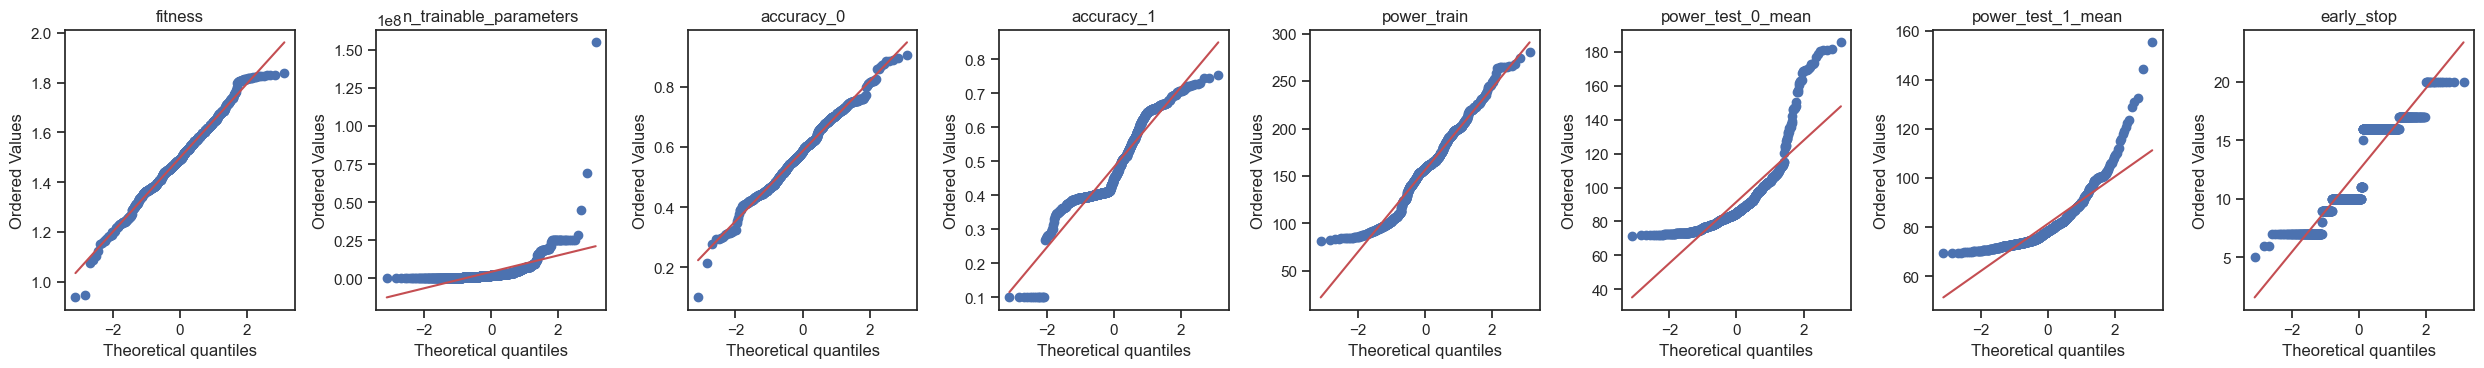

..Follows normal dist (Shapiro-Wilk test, alpha=0.05)
....fitness                  False | 0.99 | 1.15e-03
....n_trainable_parameters   False | 0.42 | 1.19e-43
....accuracy_0               False | 0.99 | 5.29e-04
....accuracy_1               False | 0.92 | 1.90e-19
....power_train              False | 0.97 | 1.20e-10
....power_test_0_mean        False | 0.75 | 2.41e-32
....power_test_1_mean        False | 0.81 | 1.48e-28
....early_stop               False | 0.84 | 8.57e-27



,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000,-0.104702,0.620226,0.434879,-0.120556,-0.288543,-0.146005,-0.225411
n_trainable_parameters,-0.104702,1.000000,0.184466,-0.043953,0.501005,0.394160,0.241454,-0.021265
accuracy_0,0.620226,0.184466,1.000000,0.351452,0.498574,0.408612,0.300944,0.084425
accuracy_1,0.434879,-0.043953,0.351452,1.000000,0.237061,0.102391,0.475368,-0.209156
power_train,-0.120556,0.501005,0.498574,0.237061,1.000000,0.892939,0.780935,0.219383
power_test_0_mean,-0.288543,0.394160,0.408612,0.102391,0.892939,1.000000,0.771338,0.237370
power_test_1_mean,-0.146005,0.241454,0.300944,0.475368,0.780935,0.771338,1.000000,0.060289
early_stop,-0.225411,-0.021265,0.084425,-0.209156,0.219383,0.237370,0.060289,1.000000


,fitness,n_trainable_parameters,accuracy_0,accuracy_1,power_train,power_test_0_mean,power_test_1_mean,early_stop
fitness,1.000000e+00,4.098464e-03,6.238900e-81,5.941357e-36,9.392270e-04,7.569577e-16,5.985964e-05,4.282630e-10
n_trainable_parameters,4.098464e-03,1.000000e+00,3.635602e-07,2.292575e-01,6.580307e-49,2.759904e-29,2.072071e-11,5.609336e-01
accuracy_0,6.238900e-81,3.635602e-07,1.000000e+00,3.167363e-23,2.220441e-48,1.510030e-31,3.638791e-17,2.075875e-02
accuracy_1,5.941357e-36,2.292575e-01,3.167363e-23,1.000000e+00,4.855483e-11,5.003890e-03,1.514639e-43,7.360421e-09
power_train,9.392270e-04,6.580307e-49,2.220441e-48,4.855483e-11,1.000000e+00,1.759451e-261,4.880866e-155,1.262066e-09
power_test_0_mean,7.569577e-16,2.759904e-29,1.510030e-31,5.003890e-03,1.759451e-261,1.000000e+00,6.032251e-149,4.575960e-11
power_test_1_mean,5.985964e-05,2.072071e-11,3.638791e-17,1.514639e-43,4.880866e-155,6.032251e-149,1.000000e+00,9.897859e-02
early_stop,4.282630e-10,5.609336e-01,2.075875e-02,7.360421e-09,1.262066e-09,4.575960e-11,9.897859e-02,1.000000e+00


In [9]:
for experiment in EXPERIMENTS_WITH_SEED:
    print(f"Experiment: {experiment}")
    fig, axes = plt.subplots(1, len(KEYS), figsize=(25, 4))
    flattened_axes = np.ndarray.flatten(axes)

    normal_str = f"..Follows normal dist (Shapiro-Wilk test, alpha={alpha})\n"
    correlation_str = "..Correlation matrix\n"
    for i, k in enumerate(KEYS):
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            k = KEYS_ENERGIZE_TO_DENSER[k]
        ax = flattened_axes[i]
        k_data = experiments_data[experiment]['data'][k]
        stats.probplot(list(k_data), dist="norm", plot=ax)
        ax.set_title(k)

        # shapiro-wilk test
        stat, p = stats.shapiro(k_data)
        normal = p > alpha
        experiments_data[experiment]['shapiro'][k] = {'stat': stat, 'p': p, 'normal': normal}
        normal_str += f"....{k:25}{colored(normal, 'green' if normal else 'red')} | {stat:.2f} | {p:.2e}\n"

    plt.tight_layout()
    plt.show()

    print(normal_str)

    # correlation coefficients
    keys = list(KEYS)
    if experiment == 'DENSER':
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]

    corr_matrix_spearman_stat = experiments_data[experiment]['data'][keys].corr(method='spearman')
    corr_matrix_spearman_p = experiments_data[experiment]['data'][keys].corr(method=lambda i, j: stats.spearmanr(i, j)[1])

    display(corr_matrix_spearman_stat)
    display(corr_matrix_spearman_p)

# Charts

fitness


<Figure size 7500x3000 with 0 Axes>

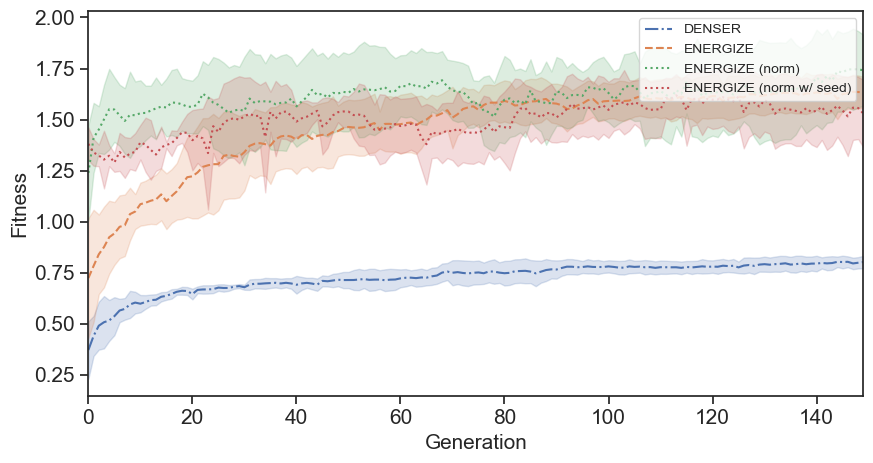

n_trainable_parameters


<Figure size 7500x3000 with 0 Axes>

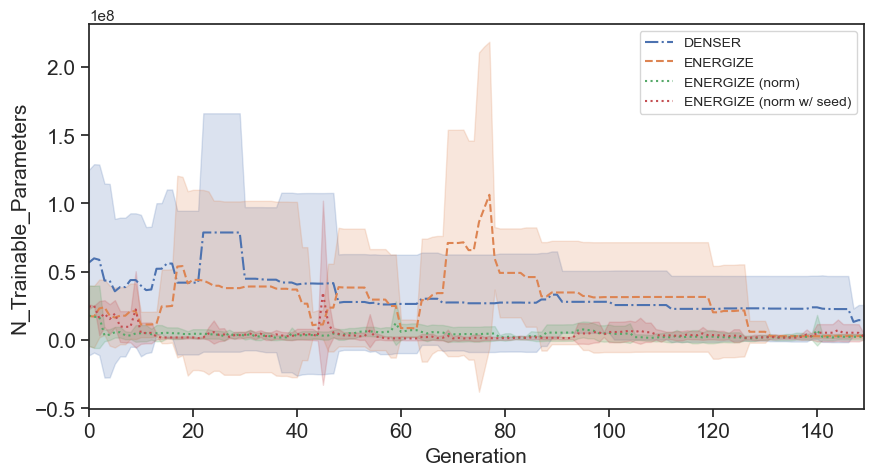

accuracy_0


<Figure size 7500x3000 with 0 Axes>

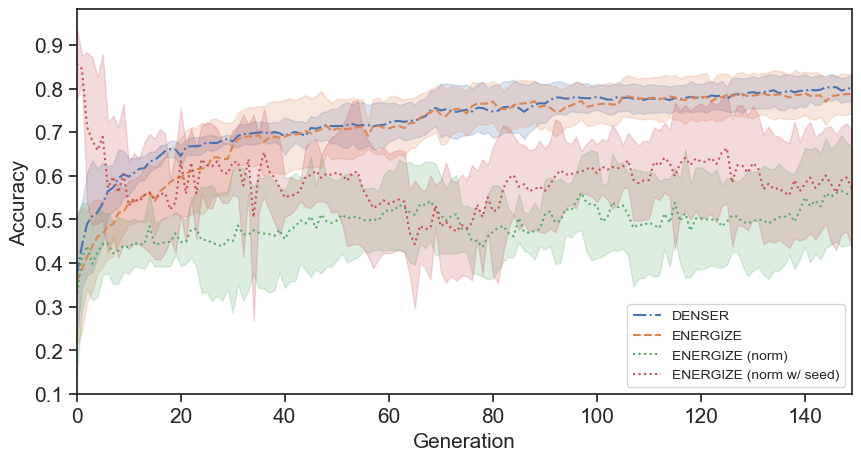

accuracy_1


<Figure size 7500x3000 with 0 Axes>

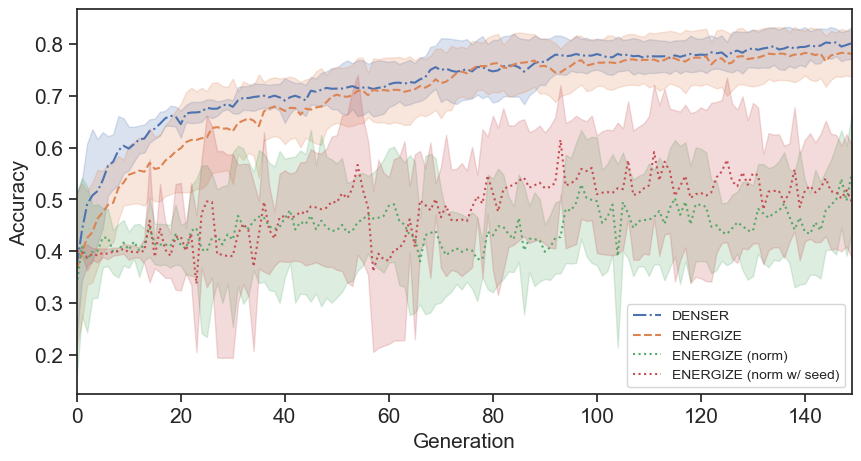

power_train


<Figure size 7500x3000 with 0 Axes>

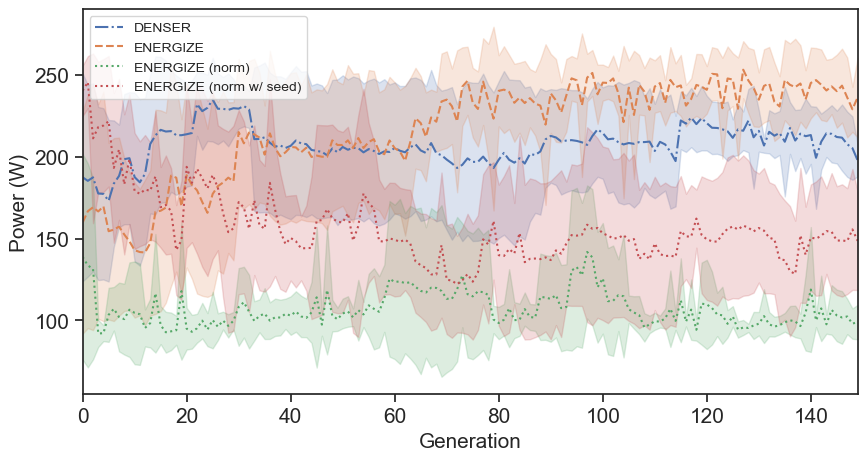

power_test_0_mean


<Figure size 7500x3000 with 0 Axes>

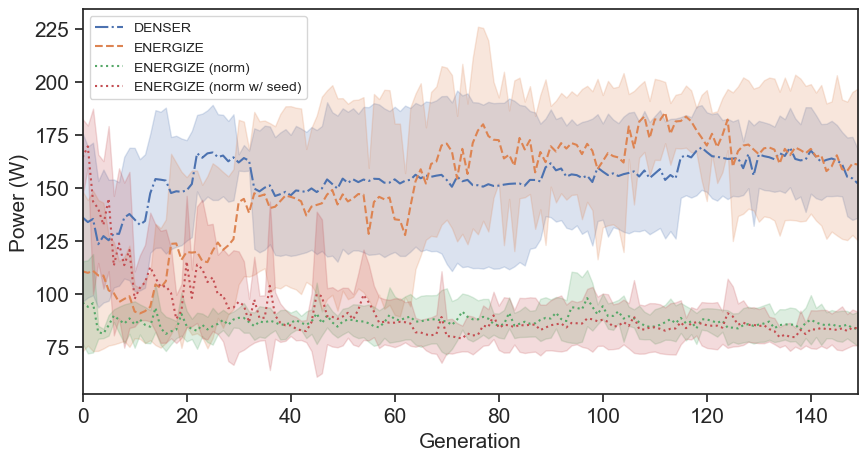

power_test_1_mean


<Figure size 7500x3000 with 0 Axes>

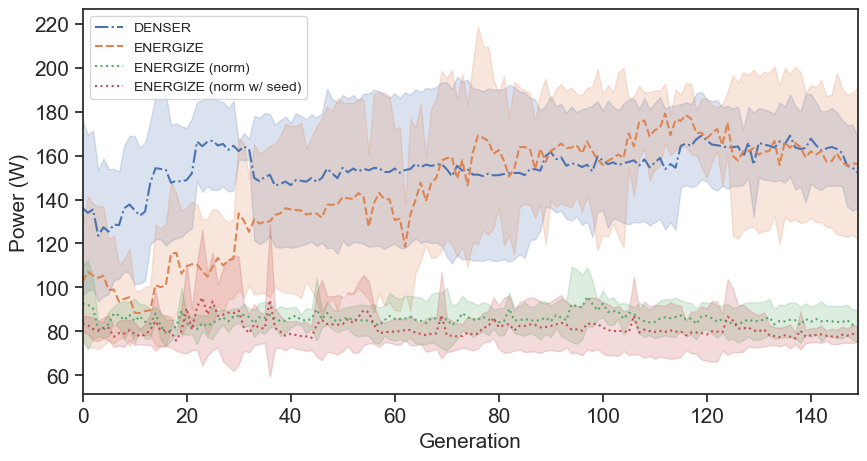

early_stop


<Figure size 7500x3000 with 0 Axes>

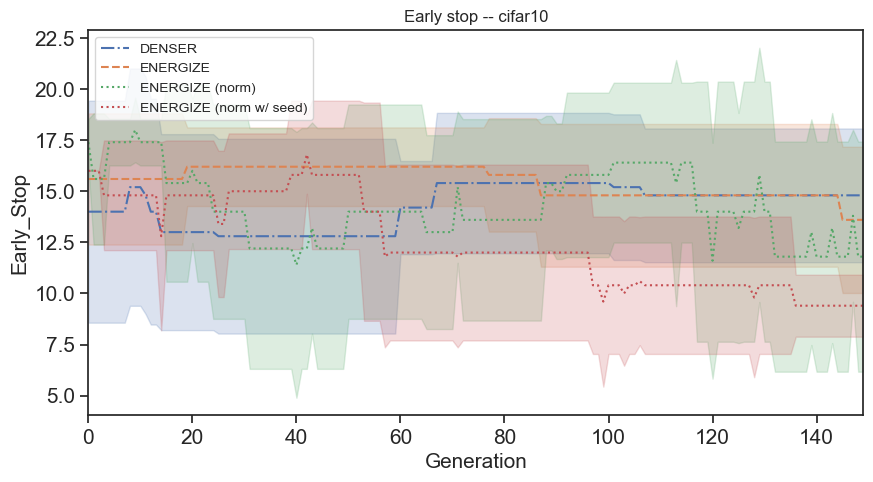

In [10]:
line_styles = {
    'DENSER': '-.',
    'ENERGIZE': '--',
    'ENERGIZE (w/ skip)': ':',
    'ENERGIZE (norm)': ':',
    'ENERGIZE (norm w/ seed)': ':'
}

for i, k in enumerate(KEYS):
    plt.figure(dpi=300)
    print(k)
    fig, ax = plt.subplots(figsize=(10, 5))
    for experiment in EXPERIMENTS:
        _k = k
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            _k = KEYS_ENERGIZE_TO_DENSER[k]
        sn.lineplot(experiments_data[experiment]['data'], x='gen', y=_k, label=experiment, ax=ax, linestyle=line_styles[experiment], errorbar="sd")
    loc = "upper right"
    if k.startswith('accuracy'):
        loc = "lower right"
    elif k.startswith('power'):
        loc = "upper left"
    elif  k == "early_stop":
        loc = "upper left"
        plt.title(f"Early stop -- {DATASET}")
    ax.legend(loc=loc, prop={'size': 10})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    ax.set_xlabel('Generation', fontsize=15)
    if k.startswith('accuracy'):
        ylabel = 'Accuracy'
        ylim = (0.75, 0.95)
    elif k.startswith('power'):
        ylabel = 'Power (W)'
        ylim = (75, 185)
    else:
        ylabel = k.title()
        ylim = None

    ylim = None
    ax.set_ylabel(ylabel, fontsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0, CUTOFF_GEN-1)

    if k in ('accuracy_0', 'power_test_0_mean'):
        plt.savefig(f"figures/{DATASET}_{k}.pdf", bbox_inches='tight')
    plt.show()

# Model partitions

<Figure size 7500x3000 with 0 Axes>

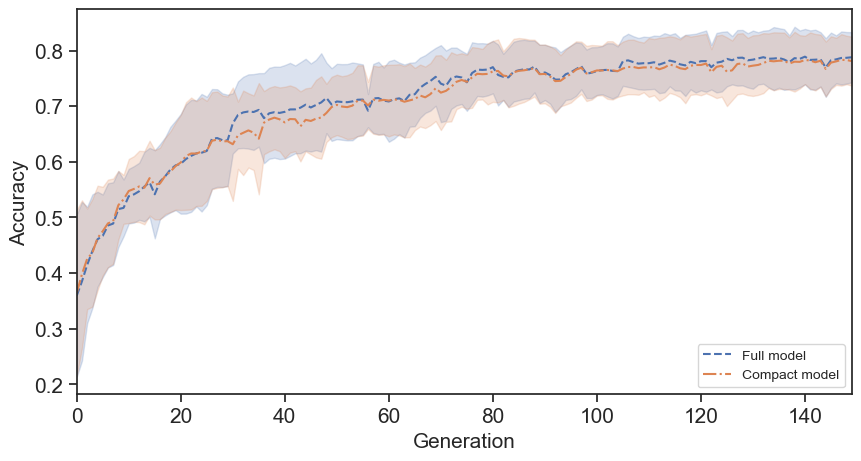

In [11]:
# accuracy
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='accuracy_0', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='accuracy_1', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Accuracy'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, CUTOFF_GEN-1)
plt.savefig(f"figures/{DATASET}_energize_partition_accuracy.pdf", bbox_inches='tight')
plt.show()

<Figure size 7500x3000 with 0 Axes>

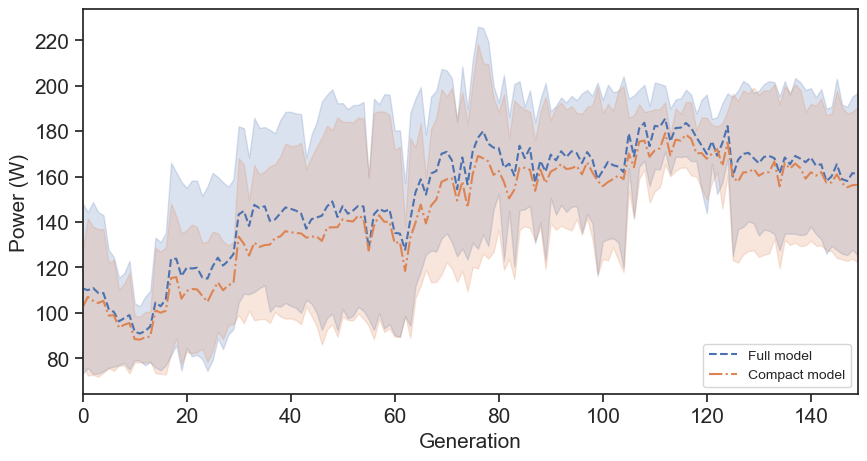

In [12]:
# power
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='power_test_0_mean', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE']['data'], x='gen', y='power_test_1_mean', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Power (W)'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, CUTOFF_GEN-1)
plt.savefig(f"figures/{DATASET}_energize_partition_power.pdf", bbox_inches='tight')
plt.show()

# Seed model

KeyError: 'ENERGIZE (w/ seed)'

<Figure size 7500x3000 with 0 Axes>

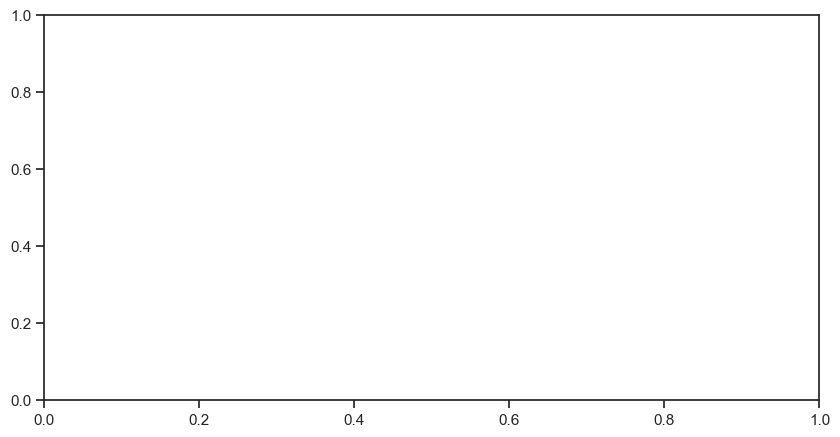

In [13]:
# seed - accuracy
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='accuracy_0', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='accuracy_1', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "lower right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Accuracy'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, 50-1)
plt.savefig(f"figures/{DATASET}_energize_seed_accuracy.pdf", bbox_inches='tight')
plt.show()

<Figure size 7500x3000 with 0 Axes>

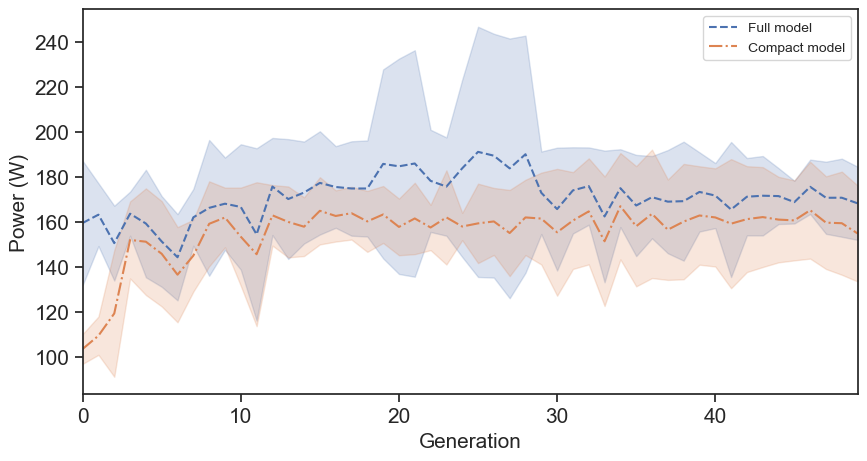

In [ ]:
# seed - power
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='power_test_0_mean', label='Full model', ax=ax, errorbar="sd", linestyle='--')
sn.lineplot(experiments_data['ENERGIZE (w/ seed)']['data'], x='gen', y='power_test_1_mean', label='Compact model', ax=ax, errorbar="sd", linestyle='-.')
loc = "upper right"
ax.legend(loc=loc, prop={'size': 10})
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_xlabel('Generation', fontsize=15)
ylabel = 'Power (W)'
ax.set_ylabel(ylabel, fontsize=15)
ax.set_xlim(0, 50-1)
plt.savefig(f"figures/{DATASET}_energize_seed_power.pdf", bbox_inches='tight')
plt.show()

power_test_0_mean
power_test_1_mean


<Figure size 7500x3000 with 0 Axes>

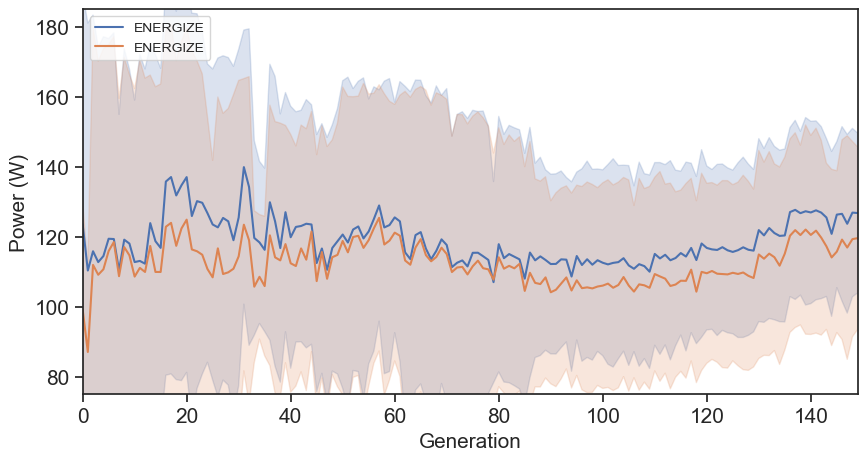

In [ ]:
plt.figure(dpi=300)
fig, ax = plt.subplots(figsize=(10, 5))
# for i, k in enumerate(('accuracy_0', 'accuracy_1')):
for i, k in enumerate(('power_test_0_mean', 'power_test_1_mean')):
    print(k)
    for experiment in EXPERIMENTS[1:2]:
        _k = k
        if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER:
            _k = KEYS_ENERGIZE_TO_DENSER[k]
        sn.lineplot(experiments_data[experiment]['data'], x='gen', y=_k, label=experiment, ax=ax, errorbar="sd")
    loc = "upper right"
    if k.startswith('accuracy'):
        loc = "lower right"
    elif k.startswith('power'):
        loc = "upper left"
    ax.legend(loc=loc, prop={'size': 10})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    ax.set_xlabel('Generation', fontsize=15)
    if k.startswith('accuracy'):
        ylabel = 'Accuracy'
        ylim = (0.75, 0.95)
    elif k.startswith('power'):
        ylabel = 'Power (W)'
        ylim = (75, 185)
    else:
        ylabel = k.title()
        ylim = None

    ax.set_ylabel(ylabel, fontsize=15)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlim(0, CUTOFF_GEN-1)

    # if k in ('accuracy_0', 'power_test_0_mean'):
    #     plt.savefig(f"figures/{k}.svg", bbox_inches='tight')
plt.show()

# Tests

Comparison (assumes normal dist is not followed)
1. Kruskal-Wallis
2. if H0 is rejected -> Mann-Whitney with Bonferroni correction

In [14]:
# group by generation and calculate mean
for experiment in EXPERIMENTS_WITH_SEED:
    keys = list(KEYS)
    if experiment == 'DENSER':
        keys = [KEYS_ENERGIZE_TO_DENSER[k] if k in KEYS_ENERGIZE_TO_DENSER else k for k in keys]
    experiments_data[experiment]['data'] = experiments_data[experiment]['data'][['gen', *keys]].groupby('gen').mean()
    if experiment == 'DENSER':
        experiments_data['DENSER']['data'] = experiments_data['DENSER']['data'].iloc[:, ~experiments_data['DENSER']['data'].columns.duplicated()]

Key: fitness
..Kruskal-Wallis test (alpha=0.05)
....stat=422.172 and p-value=3.485e-91
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,6.273998e-49,6.475919e-50,6.475919e-50
ENERGIZE,6.273998e-49,1.000000e+00,4.728015e-19,3.434192e-01
ENERGIZE (norm),6.475919e-50,4.728015e-19,1.000000e+00,8.293583e-33
ENERGIZE (norm w/ seed),6.475919e-50,3.434192e-01,8.293583e-33,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

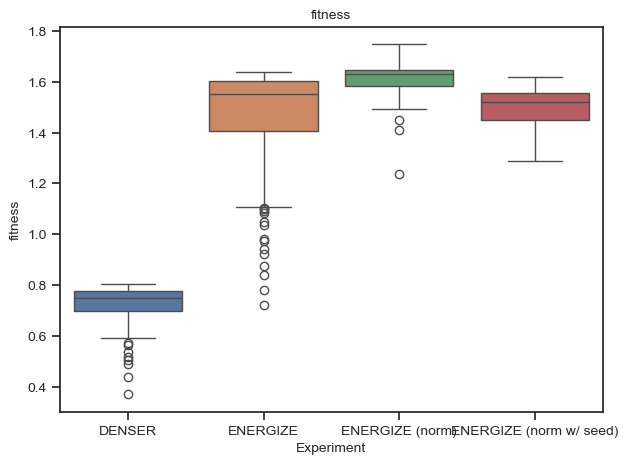

Key: n_trainable_parameters
..Kruskal-Wallis test (alpha=0.05)
....stat=377.797 and p-value=1.426e-81
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,1.000000e+00,7.687039e-50,2.957403e-48
ENERGIZE,1.000000e+00,1.000000e+00,7.485863e-35,5.265252e-35
ENERGIZE (norm),7.687039e-50,7.485863e-35,1.000000e+00,9.747291e-02
ENERGIZE (norm w/ seed),2.957403e-48,5.265252e-35,9.747291e-02,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

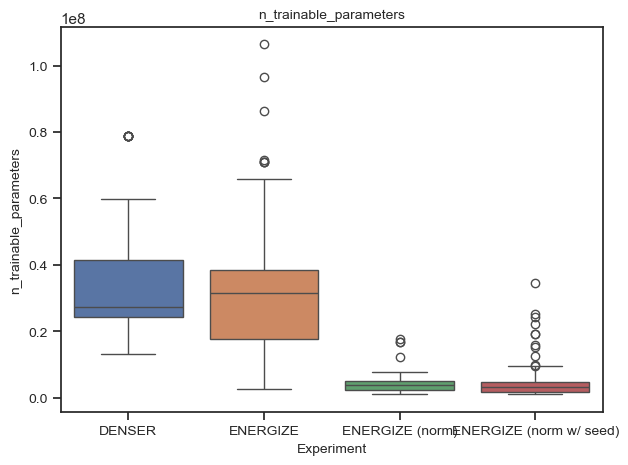

Key: accuracy_0
..Kruskal-Wallis test (alpha=0.05)
....stat=388.832 and p-value=5.811e-84
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,1.000000e+00,5.687477e-46,5.457663e-36
ENERGIZE,1.000000e+00,1.000000e+00,8.245270e-41,1.511131e-26
ENERGIZE (norm),5.687477e-46,8.245270e-41,1.000000e+00,4.500164e-37
ENERGIZE (norm w/ seed),5.457663e-36,1.511131e-26,4.500164e-37,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

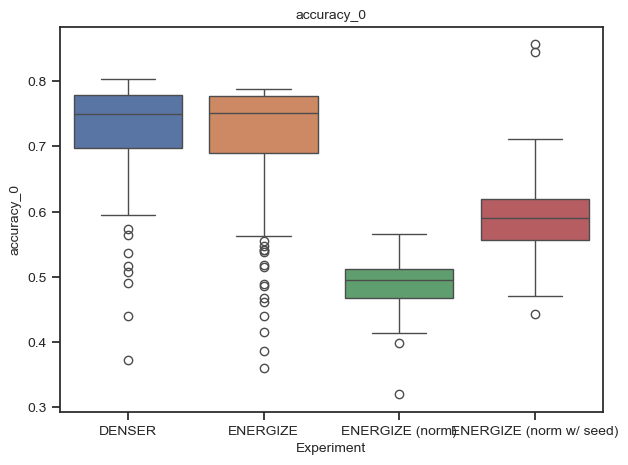

Key: accuracy_1
..Kruskal-Wallis test (alpha=0.05)
....stat=417.747 and p-value=3.169e-90
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,3.274513e-02,1.008272e-47,1.011027e-45
ENERGIZE,3.274513e-02,1.000000e+00,8.222821e-45,1.536697e-41
ENERGIZE (norm),1.008272e-47,8.222821e-45,1.000000e+00,1.199421e-09
ENERGIZE (norm w/ seed),1.011027e-45,1.536697e-41,1.199421e-09,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

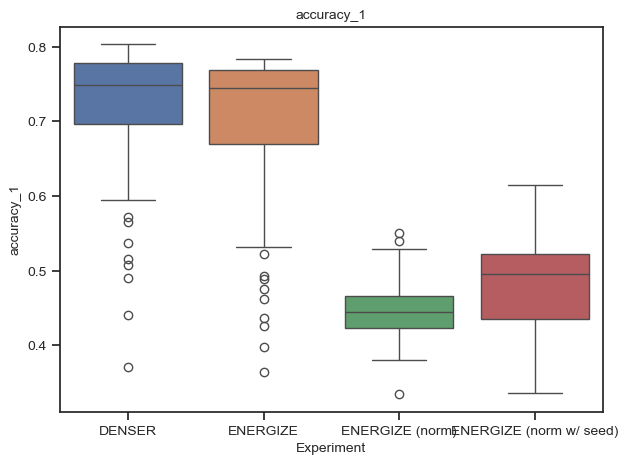

Key: power_train
..Kruskal-Wallis test (alpha=0.05)
....stat=472.016 and p-value=5.531e-102
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,4.939070e-06,6.476567e-50,7.816545e-42
ENERGIZE,4.939070e-06,1.000000e+00,6.741137e-50,9.262052e-37
ENERGIZE (norm),6.476567e-50,6.741137e-50,1.000000e+00,1.357375e-48
ENERGIZE (norm w/ seed),7.816545e-42,9.262052e-37,1.357375e-48,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

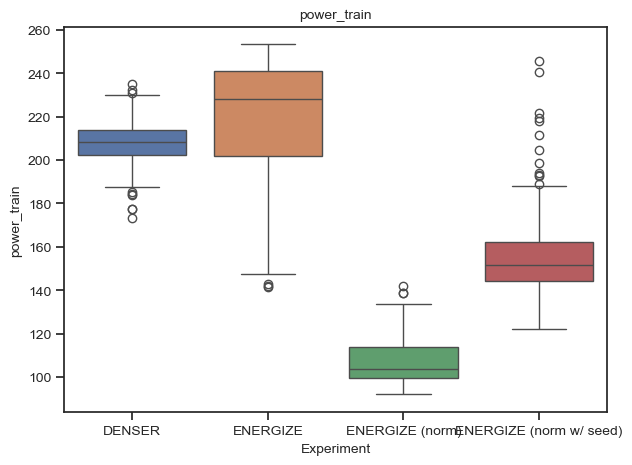

Key: power_test_0_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=428.479 and p-value=1.499e-92
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,1.000000e+00,6.476567e-50,3.951235e-47
ENERGIZE,1.000000e+00,1.000000e+00,1.529389e-49,4.582930e-44
ENERGIZE (norm),6.476567e-50,1.529389e-49,1.000000e+00,1.000000e+00
ENERGIZE (norm w/ seed),3.951235e-47,4.582930e-44,1.000000e+00,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

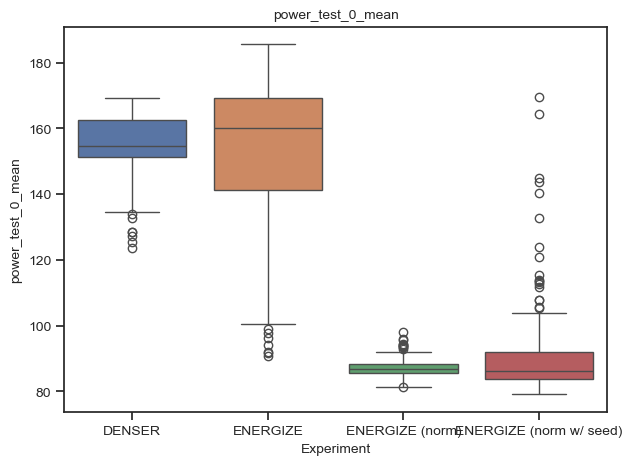

Key: power_test_1_mean
..Kruskal-Wallis test (alpha=0.05)
....stat=477.913 and p-value=2.917e-103
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,3.190870e-01,6.476567e-50,6.476567e-50
ENERGIZE,3.190870e-01,1.000000e+00,2.324077e-49,1.303760e-49
ENERGIZE (norm),6.476567e-50,2.324077e-49,1.000000e+00,1.089253e-26
ENERGIZE (norm w/ seed),6.476567e-50,1.303760e-49,1.089253e-26,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

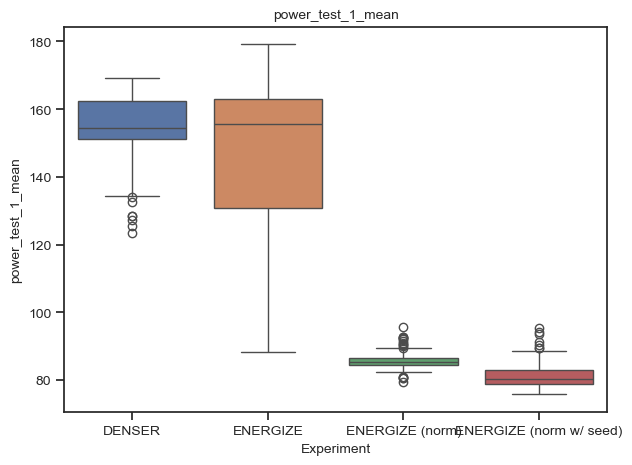

Key: early_stop
..Kruskal-Wallis test (alpha=0.05)
....stat=167.732 and p-value=3.929e-36
....reject H0 -> median is not equal across all groups
..Mann-Whitney U test (alpha=0.05, Bonferroni correction)


,DENSER,ENERGIZE,ENERGIZE (norm),ENERGIZE (norm w/ seed)
DENSER,1.000000e+00,1.206144e-20,1.000000e+00,5.601856e-12
ENERGIZE,1.206144e-20,1.000000e+00,2.288698e-10,8.811747e-28
ENERGIZE (norm),1.000000e+00,2.288698e-10,1.000000e+00,1.763326e-10
ENERGIZE (norm w/ seed),5.601856e-12,8.811747e-28,1.763326e-10,1.000000e+00


<Figure size 7500x3000 with 0 Axes>

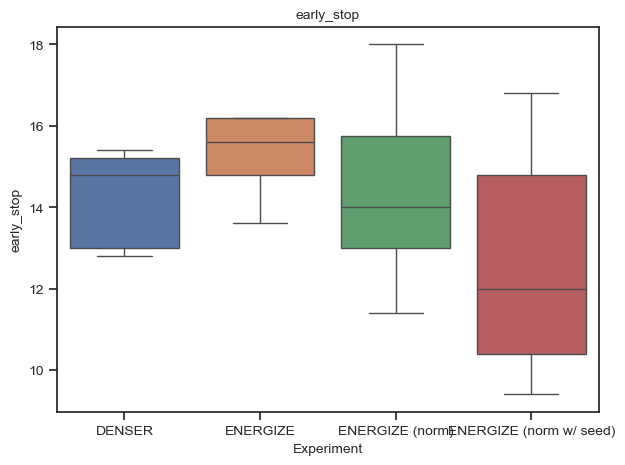

In [15]:
for i, k in enumerate(KEYS):
    print(f"Key: {k}")
    plt.figure(dpi=300)
    data = {
        experiment: experiments_data[experiment]['data'][KEYS_ENERGIZE_TO_DENSER[k] if experiment == 'DENSER' and k in KEYS_ENERGIZE_TO_DENSER else k] for experiment in EXPERIMENTS
    }
    fig, ax = plt.subplots(figsize=(7, 5))
    sn.boxplot(data, ax=ax)
    ax.set_title(k, fontsize=10)
    ax.set_xlabel('Experiment', fontsize=10)
    ax.set_ylabel(k, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=10)

    kruskal_test = stats.kruskal(*data.values())
    print(f"..Kruskal-Wallis test (alpha={alpha})")
    print(f"....stat={kruskal_test.statistic:.3f} and p-value={kruskal_test.pvalue:.3e}")
    if kruskal_test.pvalue >= alpha:
        print("....accept H0 -> median is equal across all groups")
    else:
        print("....reject H0 -> median is not equal across all groups")
        print(f"..Mann-Whitney U test (alpha={alpha}, Bonferroni correction)")
        data_df = pd.DataFrame({
            "group": [exp for exp in EXPERIMENTS for _ in range(len(data[exp]))],
            "value": [v for exp in EXPERIMENTS for v in data[exp]]
        })
        posthoc_df = sp.posthoc_mannwhitney(data_df, group_col="group", val_col="value", p_adjust="bonferroni", sort=False)
        display(posthoc_df)
    plt.show()

# Tables

In [16]:
table_rows = []

for key in KEYS:
    for experiment in EXPERIMENTS_WITH_SEED:
        _key = key
        if experiment == 'DENSER' and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data'][_key]
        row = {
            'Key': key,
            'Experiment': experiment,
            'Mean': f"{d.mean():.3f}",
            'Std': f"{d.std():.3f}",
            'Median': f"{d.median():.3f}",
            'Min': f"{d.min():.3f}",
            'Max': f"{d.max():.3f}"
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
filtered_df = df[df['Key'].isin(('accuracy', 'accuracy_0','power_test_mean', 'power_test_0_mean'))]
display(filtered_df)

percentage_diff_rows = []

for key in KEYS:
    baseline_mean = df[(df['Key'] == key) & (df['Experiment'] == 'DENSER')]['Mean'].astype(float).values[0]
    baseline_median = df[(df['Key'] == key) & (df['Experiment'] == 'DENSER')]['Median'].astype(float).values[0]

    for experiment in ['ENERGIZE', 'ENERGIZE (norm)']: # (w/ skip)
        mean_value = df[(df['Key'] == key) & (df['Experiment'] == experiment)]['Mean'].astype(float).values[0]
        median_value = df[(df['Key'] == key) & (df['Experiment'] == experiment)]['Median'].astype(float).values[0]

        mean_diff = ((mean_value - baseline_mean) / baseline_mean) * 100
        median_diff = ((median_value - baseline_median) / baseline_median) * 100

        row = {
            'Key': key,
            'Experiment': experiment,
            'Mean % Diff': f"{mean_diff:.2f}%",
            'Median % Diff': f"{median_diff:.2f}%"
        }
        percentage_diff_rows.append(row)

percentage_diff_df = pd.DataFrame(percentage_diff_rows)
filtered_percentage_diff_df = percentage_diff_df[percentage_diff_df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean'])]
display(filtered_percentage_diff_df)

,Key,Experiment,Mean,Std,Median,Min,Max
8,accuracy_0,DENSER,0.726,0.075,0.750,0.371,0.803
9,accuracy_0,ENERGIZE,0.709,0.094,0.751,0.359,0.789
10,accuracy_0,ENERGIZE (norm),0.490,0.037,0.495,0.319,0.565
11,accuracy_0,ENERGIZE (norm w/ seed),0.586,0.057,0.590,0.443,0.857
20,power_test_0_mean,DENSER,154.594,9.163,154.500,123.509,169.089
21,power_test_0_mean,ENERGIZE,151.030,24.499,160.092,90.913,185.527
22,power_test_0_mean,ENERGIZE (norm),87.194,2.846,86.749,81.288,98.102
23,power_test_0_mean,ENERGIZE (norm w/ seed),91.586,14.998,86.219,79.109,169.613


,Key,Experiment,Mean % Diff,Median % Diff
4,accuracy_0,ENERGIZE,-2.34%,0.13%
5,accuracy_0,ENERGIZE (norm),-32.51%,-34.00%
10,power_test_0_mean,ENERGIZE,-2.31%,3.62%
11,power_test_0_mean,ENERGIZE (norm),-43.60%,-43.85%


In [17]:
import pandas as pd

# Initialize an empty list to store the rows of the table
table_rows = []

for key in KEYS:
    for experiment in EXPERIMENTS_WITH_SEED:
        _key = key
        if experiment == 'DENSER' and key in KEYS_ENERGIZE_TO_DENSER:
            _key = KEYS_ENERGIZE_TO_DENSER[key]
        d = experiments_data[experiment]['data']
        best_idx = d['fitness'].idxmax()
        d = d.loc[best_idx]
        row = {
            'Key': _key,
            'Experiment': experiment,
            'Value': d[_key],
        }
        table_rows.append(row)

df = pd.DataFrame(table_rows)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
display(df[df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean', 'accuracy'])])
percentage_diff_rows = []

for key in KEYS:
    _key = key
    if key in KEYS_ENERGIZE_TO_DENSER:
        _key = KEYS_ENERGIZE_TO_DENSER[key]
    baseline_df = df[(df['Key'] == _key) & (df['Experiment'] == 'DENSER')]
    if not baseline_df.empty:
        baseline_value = baseline_df['Value'].values[0]

        for experiment in ['ENERGIZE', 'ENERGIZE (norm)']:
            experiment_df = df[(df['Key'] == key) & (df['Experiment'] == experiment)]
            if not experiment_df.empty:
                value = experiment_df['Value'].values[0]
                percentage_diff = ((value - baseline_value) / baseline_value) * 100

                row = {
                    'Key': key,
                    'Experiment': experiment,
                    'Percentage Diff': f"{percentage_diff:.2f}%"
                }
                percentage_diff_rows.append(row)

percentage_diff_df = pd.DataFrame(percentage_diff_rows)
display(percentage_diff_df[percentage_diff_df['Key'].isin(['accuracy_0', 'power_test_mean', 'power_test_0_mean', 'accuracy'])])


,Key,Experiment,Value
8,accuracy,DENSER,0.803
9,accuracy_0,ENERGIZE,0.787
10,accuracy_0,ENERGIZE (norm),0.559
11,accuracy_0,ENERGIZE (norm w/ seed),0.641
12,accuracy,DENSER,0.803
20,power_test_mean,DENSER,161.245
21,power_test_0_mean,ENERGIZE,158.075
22,power_test_0_mean,ENERGIZE (norm),84.013
23,power_test_0_mean,ENERGIZE (norm w/ seed),83.663
24,power_test_mean,DENSER,161.245


,Key,Experiment,Percentage Diff
4,accuracy_0,ENERGIZE,-2.08%
5,accuracy_0,ENERGIZE (norm),-30.40%
10,power_test_0_mean,ENERGIZE,-1.97%
11,power_test_0_mean,ENERGIZE (norm),-47.90%


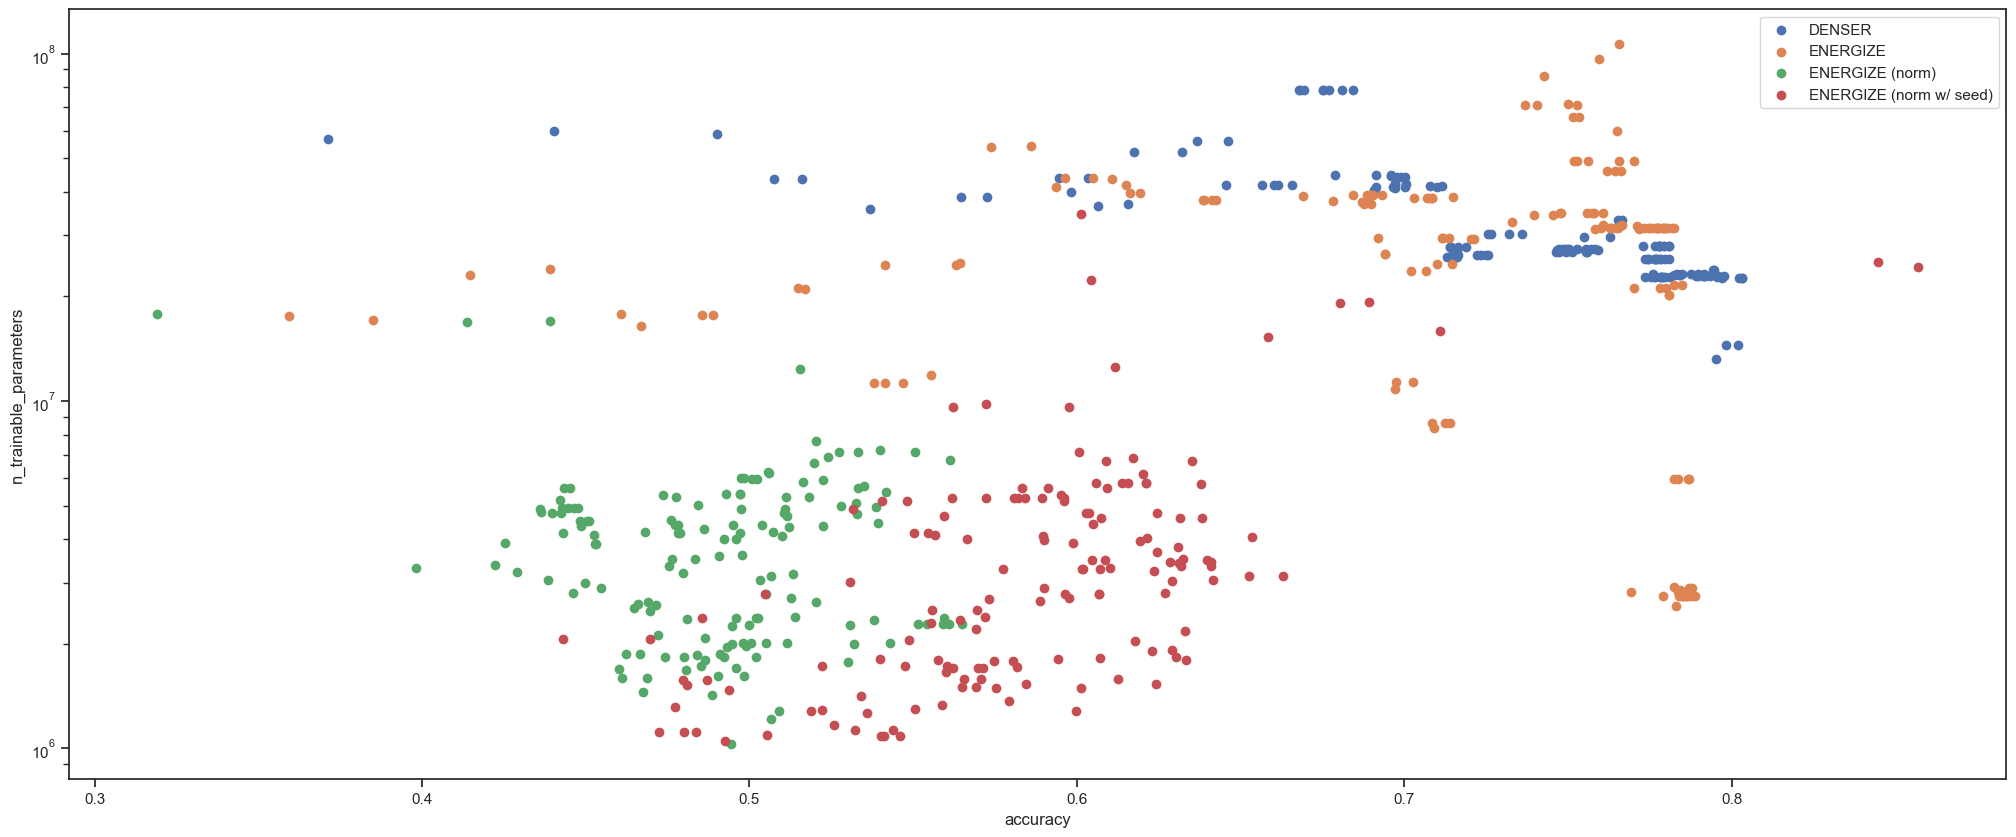

In [18]:
experiments_data
for exp in EXPERIMENTS_WITH_SEED:
    k = 'accuracy' if exp == 'DENSER' else 'accuracy_0'
    plt.scatter(experiments_data[exp]['data'][k], experiments_data[exp]['data']['n_trainable_parameters'], label=exp)
    plt.legend()
    plt.xlabel('accuracy')
    plt.ylabel('n_trainable_parameters')
    plt.yscale('log')